# Nelson–Siegel Curve Fit

A jupyter notebook that:
1. loads yield data
2. estimates the best global lambda
3. computes the three main Nelson–Siegel factors:
   - level
   - slope
   - curvature
4. plots the fitted curve for one date

### Limitations of DNS:
Cannot fit:
- multiple humps
  - Nelson–Siegel–Svensson (adds second hump)
- very irregular curves

In [129]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [130]:
# Load data
df_yields = pd.read_csv("data/yields.csv", index_col=0, parse_dates=True).dropna()
df_yields.index = pd.to_datetime(df_yields.index)
df_yields = df_yields / 100.0  # convert percent to decimal

# Maturities in years
tau = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)

df_yields.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,,,,
2010-01-04,0.0005,0.0008,0.0018,0.0045,0.0109,0.0166,0.0265,0.0336,0.0385,0.0460,0.0465
2010-01-05,0.0003,0.0007,0.0017,0.0041,0.0101,0.0157,0.0256,0.0328,0.0377,0.0454,0.0459
2010-01-06,0.0003,0.0006,0.0015,0.0040,0.0101,0.0160,0.0260,0.0333,0.0385,0.0463,0.0470
2010-01-07,0.0002,0.0005,0.0016,0.0040,0.0103,0.0162,0.0262,0.0333,0.0385,0.0462,0.0469
2010-01-08,0.0002,0.0005,0.0015,0.0037,0.0096,0.0156,0.0257,0.0331,0.0383,0.0461,0.0470


In [131]:
# Nelson–Siegel loadings
def ns_loadings(tau, lbd):
    tau = np.asarray(tau, dtype=float)
    level = np.ones_like(tau)
    slope = (1 - np.exp(-lbd * tau)) / (lbd * tau)
    curvature = slope - np.exp(-lbd * tau)
    return np.column_stack([level, slope, curvature])

## Why estimate λ using a global fit
DNS assumes λ is a structural parameter
β varies over time, λ does not

Therefore:
- λ is estimated using all data
- β_t is estimated per date

The model is:
- linear in β
- nonlinear in λ
Therefore we must search over λ using nonlinear least squares

We use grid search by:
- evaluating many λ values
- picking the best

Why?
- no closed-form solution
- function is non-convex
- grid search is robust

This approach follows the original estimation strategy of **Nelson and Siegel (1987)**, who estimate λ using nonlinear least squares via a grid search procedure.

Similar approaches are used in later term structure calibration work (e.g., **Alfaro, Becerra, and Sagner (2011)**), where λ is selected by minimizing cross-sectional fitting error.

Once λ is fixed, the model becomes linear in β and can be estimated via OLS for each date.
This becomes a linear regression problem for each date, which is computationally efficient and straightforward to implement.

In [132]:
# Estimate the best global lambda across all dates
def global_lambda_fit(df_yields, tau, lambda_grid):
    best_lambda = None
    best_error = np.inf

    for lbd in lambda_grid:
        L = ns_loadings(tau, lbd)
        total_error = 0.0

        for _, row in df_yields.iterrows():
            y = row.to_numpy()
            beta, *_ = np.linalg.lstsq(L, y, rcond=None)
            y_fit = L @ beta
            total_error += np.mean((y - y_fit) ** 2)

        # Minimizing total cross-sectional MSE across all dates
        if total_error < best_error:
            best_error = total_error
            best_lambda = lbd

    return best_lambda, best_error

lambda_grid = np.linspace(0.01, 2.0, 300)
best_lambda, best_error = global_lambda_fit(df_yields, tau, lambda_grid)

print("Best lambda:", round(best_lambda, 6))
print("Total fit error:", best_error)

Best lambda: 0.489197
Total fit error: 0.0032619797613700767


In [133]:
# Estimate level, slope, and curvature for all dates
L = ns_loadings(tau, best_lambda) # (11 x 3 matrix of loadings)

betas = []
for _, row in df_yields.iterrows():
    y = row.to_numpy()
    beta, *_ = np.linalg.lstsq(L, y, rcond=None) # (3 x 1 vector of factors)
    betas.append(beta)

df_betas = pd.DataFrame(
    betas,
    index=df_yields.index,
    columns=["Level", "Slope", "Curvature"]
)

df_betas.head()

,Level,Slope,Curvature
DATE,,,
2010-01-04,0.053853,-0.055186,-0.025677
2010-01-05,0.053394,-0.054713,-0.027819
2010-01-06,0.054635,-0.056071,-0.029024
2010-01-07,0.054404,-0.055948,-0.027847
2010-01-08,0.054699,-0.056164,-0.030380


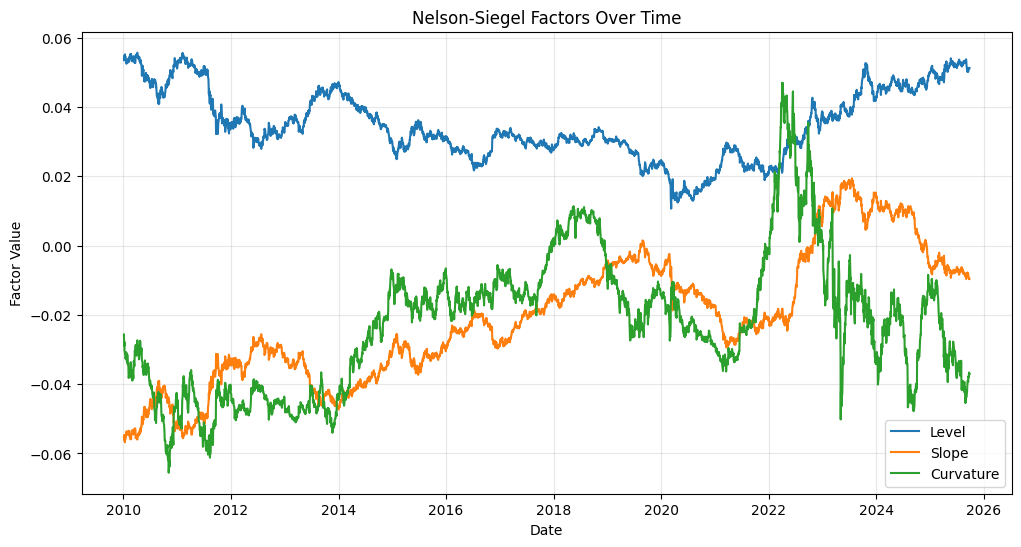

In [134]:
# Plot the three main factors over time
plt.figure(figsize=(12, 6))
plt.plot(df_betas.index, df_betas["Level"], label="Level")
plt.plot(df_betas.index, df_betas["Slope"], label="Slope")
plt.plot(df_betas.index, df_betas["Curvature"], label="Curvature")
plt.title("Nelson-Siegel Factors Over Time")
plt.xlabel("Date")
plt.ylabel("Factor Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

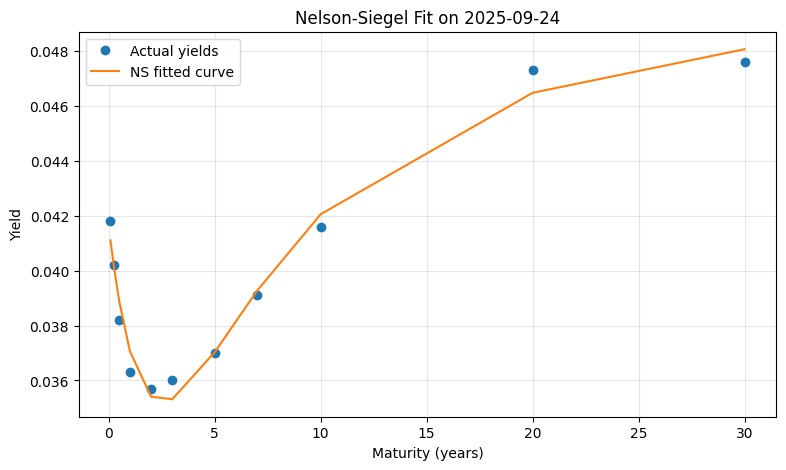

In [135]:
# Show the curve fit for one date
date = df_yields.index[-1]  # most recent date

y = df_yields.loc[date].to_numpy()
beta = df_betas.loc[date].to_numpy()
y_fit = L @ beta # (11 x 1 vector of fitted yields)

plt.figure(figsize=(9, 5))
plt.plot(tau, y, 'o', label="Actual yields")
plt.plot(tau, y_fit, '-', label="NS fitted curve")
plt.title(f"Nelson-Siegel Fit on {date.date()}")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

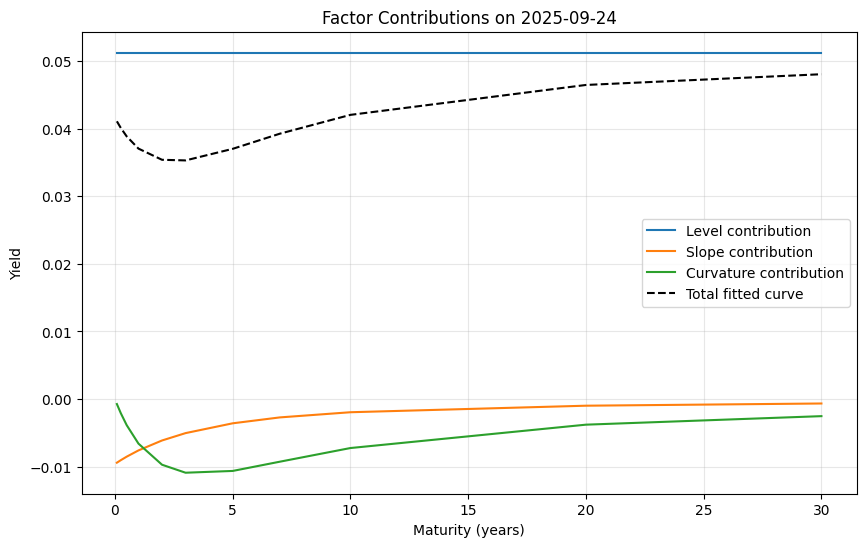

In [136]:
# Plot factor contributions for the same date
level_contrib = beta[0] * L[:, 0]
slope_contrib = beta[1] * L[:, 1]
curvature_contrib = beta[2] * L[:, 2]

plt.figure(figsize=(10, 6))
plt.plot(tau, level_contrib, label="Level contribution")
plt.plot(tau, slope_contrib, label="Slope contribution")
plt.plot(tau, curvature_contrib, label="Curvature contribution")
plt.plot(tau, y_fit, 'k--', label="Total fitted curve")
plt.title(f"Factor Contributions on {date.date()}")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

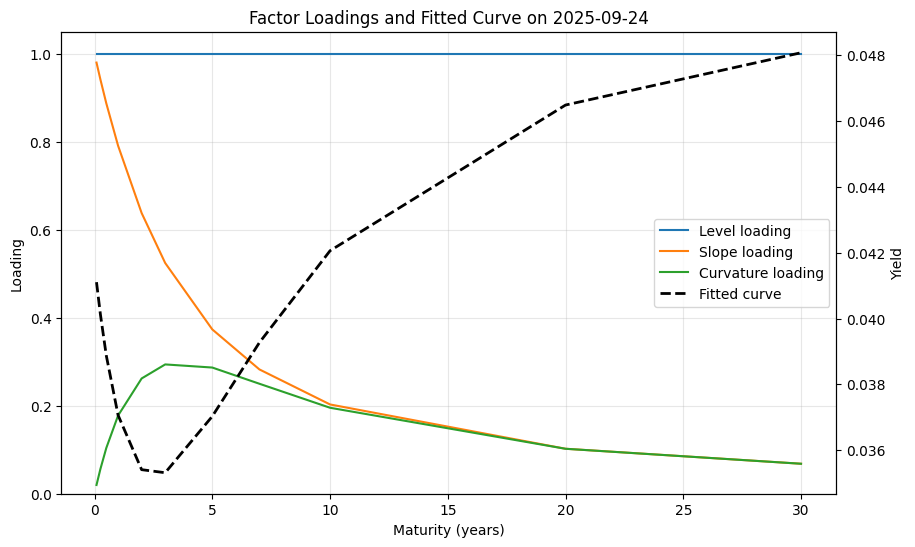

In [ ]:
# Plot Nelson–Siegel factor loading shapes relative to yield curve

fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis: factor loading shapes
ax1.plot(tau, L[:, 0], label="Level loading")
ax1.plot(tau, L[:, 1], label="Slope loading")
ax1.plot(tau, L[:, 2], label="Curvature loading")
ax1.set_xlabel("Maturity (years)")
ax1.set_ylabel("Loading")
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Right axis: fitted yield curve
ax2 = ax1.twinx()
ax2.plot(tau, y_fit, 'k--', linewidth=2, label="Fitted curve")
ax2.set_ylabel("Yield")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title(f"Factor Loadings and Fitted Curve on {date.date()}")
plt.show()